# BESTEST LBNL-style report — Case 600 pilot

Native Python ISO results may be used for formal ASHRAE annual-energy assessment. `modelica_solar` is a controlled-forcing comparison and is not formal pass/fail.

In [1]:
from pathlib import Path
import subprocess, sys
import matplotlib.pyplot as plt
import pandas as pd

ISO_MODE = 'modelica_solar'  # accepted: 'modelica_solar', 'native'
cwd = Path.cwd().resolve()
root = next((p for p in (cwd, *cwd.parents) if (p / 'scripts/bestest_iso_run_case600_pilot.py').is_file()), None)
if root is None:
    candidate = cwd / '2__validation/_BESTEST'
    if not (candidate / 'scripts/bestest_iso_run_case600_pilot.py').is_file():
        raise FileNotFoundError('Open from _BESTEST or _development.')
    root = candidate
sys.path.insert(0, str(root / 'scripts'))
from bestest_iso_reporting import (MODELICA_LABEL, annual_energy_table, daily_slice, peak_table, selected_hourly, selected_iso_mode)
subprocess.run([sys.executable, 'scripts/bestest_iso_run_case600_pilot.py'], cwd=root, check=True)
reference = root / '_ref/BESTEST_LBNL_all_cases_reference.md'
case = '600'
result_dir = root / 'results' / '1_iso' / f'case{case}'
metrics = pd.read_csv(result_dir / f'case{case}_metrics.csv')
hourly = pd.read_csv(result_dir / f'case{case}_feb1_load_profile.csv')
iso_run_mode, ISO_LABEL = selected_iso_mode(ISO_MODE)
def annual_range_plot(table, title):
    row = table.iloc[0]
    values = row.drop(labels=['Case', 'ASHRAE lower', 'ASHRAE upper', 'Python range status']).astype(float)
    fig, ax = plt.subplots(figsize=(9, 3.4))
    ax.bar(values.index, values.values, color='#4C78A8')
    ax.axhline(row['ASHRAE lower'], color='#555555', linestyle='--', label='ASHRAE lower')
    ax.axhline(row['ASHRAE upper'], color='#555555', linestyle='--', label='ASHRAE upper')
    ax.set(ylim=(0, 1.2 * max(values.max(), row['ASHRAE upper'])), ylabel='MWh', title=title)
    ax.legend(); ax.grid(axis='y', alpha=.2); plt.xticks(rotation=45, ha='right'); fig.tight_layout(); plt.show()

## 1. Annual heating energy

Annual heating energy for the implemented conditioned case, in MWh.

,Case,ASHRAE lower,ASHRAE upper,BSIMAC,CSE,DeST,EnergyPlus,ESP-r,TRNSYS,Modelica native,Python ISO 13790 + Modelica-resolved solar,Python range status
0,600,3.75,4.98,4.05,3.993,4.047,4.324,4.362,4.504,4.657997,4.582236,PASS — diagnostic


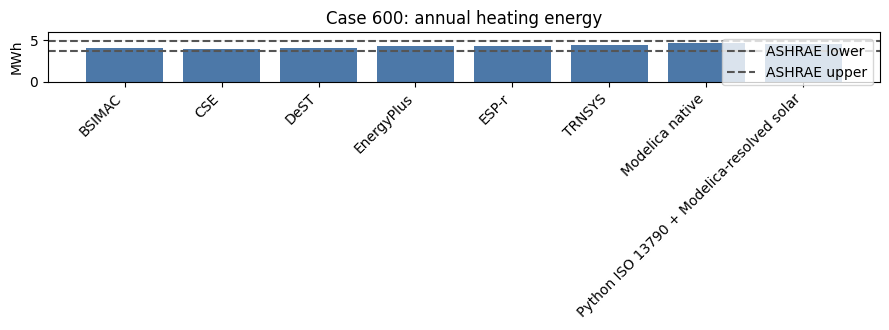

In [2]:
heating = annual_energy_table(metrics, reference, case, 'annual_heating_energy', ISO_MODE)
display(heating)
annual_range_plot(heating, f'Case {case}: annual heating energy')

## 2. Annual cooling energy

Annual cooling energy for the implemented conditioned case, in MWh.

,Case,ASHRAE lower,ASHRAE upper,BSIMAC,CSE,DeST,EnergyPlus,ESP-r,TRNSYS,Modelica native,Python ISO 13790 + Modelica-resolved solar,Python range status
0,600,5.0,6.83,5.822,5.913,5.432,6.027,6.162,5.78,5.802666,5.727737,PASS — diagnostic


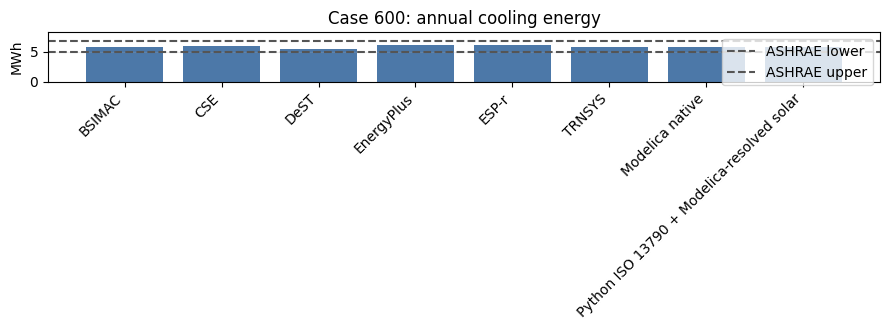

In [3]:
cooling = annual_energy_table(metrics, reference, case, 'annual_cooling_energy', ISO_MODE)
display(cooling)
annual_range_plot(cooling, f'Case {case}: annual cooling energy')

## 3. Peak heating load

Peak heating load and completed-hour occurrence time, in kW.

In [4]:
display(peak_table(metrics, reference, case, 'peak_heating_load', ISO_MODE))

,Case,BSIMAC,CSE,DeST,EnergyPlus,ESP-r,TRNSYS,Modelica native,Python ISO 13790 + Modelica-resolved solar
0,600,3.255 (26-Nov:8),3.020 (01-Jan:1),3.035 (01-Jan:0),3.204 (31-Dec:24),3.228 (01-Jan:1),3.359 (01-Jan:1),3.233 (01-Jan:00),3.317 (01-Jan:00)


## 4. Peak cooling load

Peak cooling load and completed-hour occurrence time, in kW.

In [5]:
display(peak_table(metrics, reference, case, 'peak_cooling_load', ISO_MODE))

,Case,BSIMAC,CSE,DeST,EnergyPlus,ESP-r,TRNSYS,Modelica native,Python ISO 13790 + Modelica-resolved solar
0,600,5.650 (22-Jan:15),6.481 (22-Jan:14),5.422 (22-Jan:14),6.352 (22-Jan:14),6.193 (22-Jan:14),6.046 (22-Jan:14),5.570 (22-Jan:14),5.516 (22-Jan:14)


## 5. Daily load profile

Case 600 heating and cooling hourly averages on 1 February, plotted at completed hours 1–24. The figure compares Modelica native with Python ISO 13790 using Modelica-resolved solar; neither series is shifted.

,physical_interval,modelica_raw_timestamp,modelica_completed_hour,iso_raw_timestamp,iso_completed_hour,modelica_heating_W,iso_heating_W,modelica_cooling_W,iso_cooling_W
5,01-Feb 05:00–06:00,2700000.0,6,2700000.0,6,2.341277e+03,2348.166168,-0.000000,0.000000
6,01-Feb 06:00–07:00,2703600.0,7,2703600.0,7,2.343777e+03,2255.378048,-0.000000,0.000000
7,01-Feb 07:00–08:00,2707200.0,8,2707200.0,8,2.024111e+03,1588.062535,-0.000000,0.000000
8,01-Feb 08:00–09:00,2710800.0,9,2710800.0,9,8.384018e+02,144.512843,-0.000000,0.000000
9,01-Feb 09:00–10:00,2714400.0,10,2714400.0,10,-4.086081e-03,0.000000,-0.000000,0.000000
10,01-Feb 10:00–11:00,2718000.0,11,2718000.0,11,-3.418658e-07,0.000000,918.070704,1684.095394
11,01-Feb 11:00–12:00,2721600.0,12,2721600.0,12,0.000000e+00,0.000000,2656.377232,3102.676901
16,01-Feb 16:00–17:00,2739600.0,17,2739600.0,17,0.000000e+00,0.000000,1712.934621,962.313876
17,01-Feb 17:00–18:00,2743200.0,18,2743200.0,18,0.000000e+00,0.000000,190.412101,0.000000
18,01-Feb 18:00–19:00,2746800.0,19,2746800.0,19,5.080563e+01,233.239966,-0.000001,0.000000


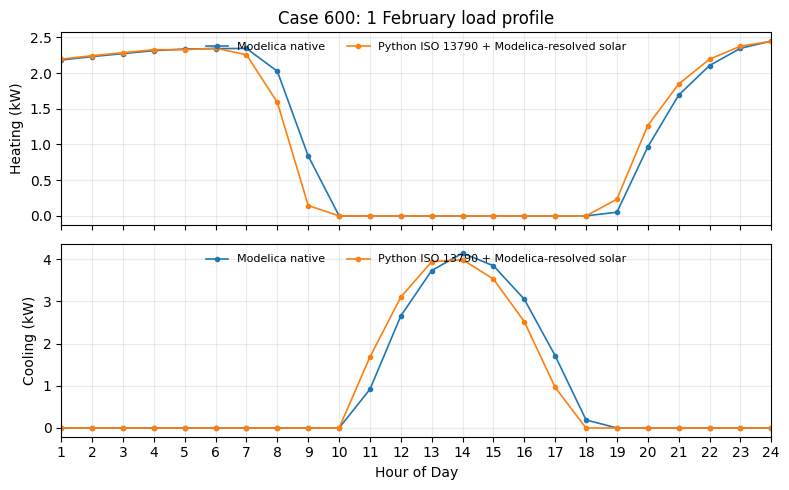

In [6]:
subprocess.run([sys.executable, 'scripts/bestest_iso_audit_case600_timestamps.py', '--iso-mode', ISO_MODE], cwd=root, check=True)
alignment = pd.read_csv(result_dir / f'case600_feb1_timestamp_alignment_{ISO_MODE}.csv')
display(alignment[alignment.modelica_completed_hour.isin([*range(6, 13), *range(17, 23)])])
profile = daily_slice(selected_hourly(hourly, 'modelica_solar'), 2, 1)
profile['run'] = profile.implementation.map({'modelica': MODELICA_LABEL, 'iso13790': 'Python ISO 13790 + Modelica-resolved solar'})
fig, axes = plt.subplots(2, 1, figsize=(8, 5), sharex=True)
for run, frame in profile.groupby('run'):
    frame = frame.sort_values('hour')
    axes[0].plot(frame.hour, frame.heating_load_W / 1000, marker='o', markersize=3, linewidth=1.2, label=run)
    axes[1].plot(frame.hour, frame.cooling_load_W / 1000, marker='o', markersize=3, linewidth=1.2, label=run)
axes[0].set(ylabel='Heating (kW)', title='Case 600: 1 February load profile')
axes[1].set(xlabel='Hour of Day', ylabel='Cooling (kW)', xlim=(1, 24), xticks=range(1, 25))
for axis in axes: axis.grid(alpha=.25); axis.legend(loc='upper center', ncol=2, fontsize=8, frameon=False)
fig.tight_layout(); plt.show()

## Summary

Current Case 600 annual-energy record; the main report uses the selected `ISO_MODE`.

In [7]:
summary = metrics[metrics.metric.isin(['annual_heating_energy', 'annual_cooling_energy'])].copy()
summary['Run'] = summary.apply(lambda x: MODELICA_LABEL if x.implementation == 'modelica' else ('Native ISO' if x.run_mode == 'native' else 'ISO + Modelica solar'), axis=1)
energy = summary.pivot(index='Run', columns='metric', values='value').rename(columns={'annual_heating_energy': 'Heating (MWh)', 'annual_cooling_energy': 'Cooling (MWh)'}).reindex(['Native ISO', 'ISO + Modelica solar', MODELICA_LABEL])
formal = pd.read_csv(result_dir / f'case{case}_formal_ashrae_energy.csv')
bounds = formal.drop_duplicates('metric').set_index('metric')[['lower', 'upper']]
def annual_status(run, metric):
    value = energy.loc[run, 'Heating (MWh)' if metric == 'annual_heating_energy' else 'Cooling (MWh)']
    status = 'PASS' if bounds.loc[metric, 'lower'] <= value <= bounds.loc[metric, 'upper'] else 'FAIL'
    return f'{status}' if run == 'ISO + Modelica solar' else status
summary_table = pd.DataFrame([{
    'Run': run,
    'Heating (MWh)': energy.loc[run, 'Heating (MWh)'],
    'Heating range (MWh)': f"{bounds.loc['annual_heating_energy', 'lower']:.2f}–{bounds.loc['annual_heating_energy', 'upper']:.2f}",
    'Heating status': annual_status(run, 'annual_heating_energy'),
    'Cooling (MWh)': energy.loc[run, 'Cooling (MWh)'],
    'Cooling range (MWh)': f"{bounds.loc['annual_cooling_energy', 'lower']:.2f}–{bounds.loc['annual_cooling_energy', 'upper']:.2f}",
    'Cooling status': annual_status(run, 'annual_cooling_energy'),
} for run in energy.index])
display(summary_table)
print('Controlled-forcing ISO is close to Modelica; native ISO remains affected by the unresolved solar-preprocessing discrepancy. The main report uses ISO_MODE =', ISO_MODE)

,Run,Heating (MWh),Heating range (MWh),Heating status,Cooling (MWh),Cooling range (MWh),Cooling status
0,Native ISO,5.502373,3.75–4.98,FAIL,1.413772,5.00–6.83,FAIL
1,ISO + Modelica solar,4.582236,3.75–4.98,PASS,5.727737,5.00–6.83,PASS
2,Modelica native,4.657997,3.75–4.98,PASS,5.802666,5.00–6.83,PASS


Controlled-forcing ISO is close to Modelica; native ISO remains affected by the unresolved solar-preprocessing discrepancy. The main report uses ISO_MODE = modelica_solar
